# 瞬态热传导问题求解(含太阳热源, 自适应权重方法)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from typing import List, Optional

# 常用工具

In [2]:
# 定义全连接神经网络和自动求导函数
class FCNN(nn.Module):
    def __init__(self, input_dimension, output_dimension,
                 n_hidden_layers, neurons,
                 regularization_param=0., regularization_exp=1.,
                 retrain_seed=40):
        super(FCNN, self).__init__()
        
        self.input_dimension = input_dimension
        self.output_dimension = output_dimension
        self.neurons = neurons
        self.n_hidden_layers = n_hidden_layers
        self.activation = nn.LeakyReLU()
        self.regularization_param = regularization_param
        self.regularization_exp = regularization_exp

        self.input_layer = nn.Linear(self.input_dimension, self.neurons)
        self.hidden_layers = nn.ModuleList([nn.Linear(self.neurons, self.neurons) for _ in range(n_hidden_layers - 1)])
        self.output_layer = nn.Linear(self.neurons, self.output_dimension)
        self.retrain_seed = retrain_seed
        self.init_xavier()
    
    def forward(self, x):
        x = self.activation(self.input_layer(x))
        for k, l in enumerate(self.hidden_layers):
            x = self.activation(l(x))
        return self.output_layer(x)

    def init_xavier(self):
        torch.manual_seed(self.retrain_seed)
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                g = nn.init.calculate_gain('tanh')
                torch.nn.init.xavier_uniform_(m.weight, gain=g)
                #torch.nn.init.xavier_normal_(m.weight, gain=g)
                m.bias.data.fill_(0)
        self.apply(init_weights)

    def regularization(self):
        reg_loss = 0
        for name, param in self.named_parameters():
            if 'weight' in name:
                reg_loss = reg_loss + torch.norm(param, self.regularization_exp)
        return self.regularization_param * reg_loss

def autograd(y: torch.Tensor, x: List[torch.Tensor]) -> List[torch.Tensor]:
    grad_outputs: List[Optional[torch.Tensor]] = [torch.ones_like(y, device=y.device)]

    grad = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=grad_outputs,
        create_graph=True,
        allow_unused=True,
    )
    
    grad = [g if g is not None else torch.zeros_like(xx) for xx, g in zip(x, grad)]
    
    return grad

def relative_error(U_pred, U_true):
    with torch.no_grad():
        return torch.linalg.vector_norm(U_pred-U_true)/torch.linalg.vector_norm(U_true) * 100

def generate_mesh(N, Nt, t_max=1, no_interior=True):
    linspace = torch.linspace(0, 1, N)
    x, y, z, t = torch.meshgrid(linspace, linspace, linspace, torch.linspace(0, t_max, Nt), indexing='ij')
    mesh = torch.stack([x, y, z, t], dim=-1).reshape(-1, 4)
    if no_interior:
        mask = (mesh[:, 0] == 0) | (mesh[:, 0] == 1) | (mesh[:, 1]==0) | (mesh[:, 1]==1) | (mesh[:, 2]==0) | (mesh[:, 2]==1)
        mesh = mesh[mask]
    return mesh

# 数据导入

In [3]:
data = pd.read_csv("data_7251s_cleaned.txt", delimiter=' ', header=None)
X = torch.tensor(data.iloc[:, :3].to_numpy(), dtype=torch.float32)
Ut = torch.tensor(data.iloc[:, 3:].to_numpy(), dtype=torch.float32)

In [4]:
def convert_tensor(X, Ut, max_time=1.0):
    Nt = Ut.shape[1]
    Xt = torch.zeros((len(X) * Nt, 4))
    U = torch.zeros((len(X) * Nt, 1))

    for i in range(len(X)):
        for j in range(Nt):
            idx = i*Nt + j
            Xt[idx, :3] = X[i, :]
            Xt[idx, 3] = max_time*j/Nt
            U[idx] = Ut[i, j]
    return Xt, U

In [5]:
max_time=1.0
Xt, U = convert_tensor(X, Ut, max_time)

In [6]:
Xt_mesh = generate_mesh(7, 5, 1.0, no_interior=True)

# 无监督数据PINN

In [7]:
class PINN:
    def __init__(self, lambdas,
                 n_hidden_layers=3, neurons=8,
                 T0    = 273.,
                 rho   = 1.,
                 C_rho = 1.,
                 k     = 1,
                 Qb    = 100.,
                 epsilon   = 0.1,
                 sigma = 5.67e-8,
                 T_amb = 3.
                ):
        # 损失函数权重
        self.lambdas = lambdas.clone().detach().requires_grad_(True)
        self.params_to_train = [self.lambdas]

        # 神经网络函数 
        self.u = FCNN(input_dimension=4, output_dimension=1,
                         n_hidden_layers=n_hidden_layers, neurons=neurons,
                         regularization_param=1., regularization_exp=2.,
                         retrain_seed=0)

        self.T0 = T0
        self.rho = rho
        self.C_rho = C_rho
        self.k = k
        self.Qb = Qb
        self.epsilon = epsilon
        self.sigma = sigma
        self.T_amb = T_amb


    def set_lambdas(self, lambdas):
        self.lambdas = lambdas


    # 神经网络预测函数
    def predict(self, Xt):
        return self.u(Xt)

    # 计算损失函数
    def compute_losses(self, Xt_mesh):
        # 自动微分计算
        # uXt: 神经网络在Xt_mesh上的取值
        # Du: u关于位置的梯度
        # Dt: u关于时间的偏导
        Xt_mesh.requires_grad = True
        uXt = self.predict(Xt_mesh)
        grad = autograd(uXt, Xt_mesh)[0]
        Du = grad[:, :3]
        Dt = grad[:, -1].reshape(-1, 1)
        Dx, Dy, Dz = Du.T
        Dx = Dx.reshape(-1, 1)
        Dy = Dy.reshape(-1, 1)
        Dy = Dy.reshape(-1, 1)
        Dxx = autograd(Dx, Xt_mesh)[0].T[0].reshape(-1,1)
        Dyy = autograd(Dy, Xt_mesh)[0].T[1].reshape(-1,1)
        Dzz = autograd(Dz, Xt_mesh)[0].T[2].reshape(-1,1)
        Xt_mesh.requires_grad = False

        # PDE残差
        loss_pde = torch.mean((self.rho*self.C_rho* Dt  - self.k*(Dxx+Dyy+Dzz) )**2)
        
        # 初始条件残差
        mask = (Xt_mesh[:, -1] == 0)
        loss_ic = max(torch.mean((uXt[mask] - self.T0) **2) - 1e-1, torch.tensor(0.0))

        mask = (Xt_mesh[:, 0] == 0) 
        loss_bc = torch.mean((-self.k*Dx[mask] - self.epsilon*self.sigma*(self.T_amb**4 - uXt[mask]**4) )**2)

        mask = (Xt_mesh[:, 0] == 1) 
        loss_bc_s = torch.mean((self.k*Dx[mask] -  self.Qb)**2)

        mask = (Xt_mesh[:, 1] == 0) 
        loss_bc = torch.mean((-self.k*Dy[mask] - self.epsilon*self.sigma*(self.T_amb**4 - uXt[mask]**4) )**2)

        mask = (Xt_mesh[:, 1] == 1) 
        loss_bc += torch.mean((self.k*Dy[mask] - self.epsilon*self.sigma*(self.T_amb**4 - uXt[mask]**4) )**2)

        mask = (Xt_mesh[:, 2] == 0) 
        loss_bc += torch.mean((-self.k*Dz[mask] - self.epsilon*self.sigma*(self.T_amb**4 - uXt[mask]**4) )**2)

        mask = (Xt_mesh[:, 2] == 1) 
        loss_bc += torch.mean((self.k*Dz[mask] - self.epsilon*self.sigma*(self.T_amb**4 - uXt[mask]**4) )**2)

        losses = torch.hstack([loss_pde, loss_ic, loss_bc, loss_bc_s])
        total_loss = (1/(2*self.lambdas**2))@losses + torch.log(self.lambdas).sum().reshape(-1,)
        return total_loss, losses


    def train(self, Xt_mesh,
             epochs=1000, lr=1e-3,
             verbose=True):
        
        opt = optim.Adam([{'params': self.u.parameters()}, {'params': self.params_to_train}], lr=lr)
        #scheduler = optim.lr_scheduler.StepLR(opt, step_size=50, gamma=0.1)

        errs = []
        history = []
        history_pde = []
        history_ic = []
        history_bc = []
        history_bc_s = []

        for epoch in range(epochs):
            opt.zero_grad()
            total_loss, losses = self.compute_losses(Xt_mesh)
            loss_pde, loss_ic, loss_bc, loss_bc_s = losses
            total_loss.backward()
            opt.step()
            #scheduler.step()
            
            with torch.no_grad():
                if verbose:
                    percentage = round(100 * epoch / epochs, 1)
                    losses_str = ', '.join([f"{loss:.4f}" for loss in losses.cpu().numpy()])
                    lambdas_str = ', '.join([f"{l:.4f}" for l in self.lambdas.cpu().numpy()])
                    print(f"\r[{percentage}%] losses: [{losses_str}] | lambdas: [{lambdas_str}] | total loss: [{total_loss.item()}]", end='')
                
            errs.append(relative_error(self.u(Xt), U))
            history.append(total_loss.item())
            history_pde.append(loss_pde.item())
            history_ic.append(loss_ic.item())
            history_bc.append(loss_bc.item())
            history_bc_s.append(loss_bc_s.item())

        return history, history_pde, history_ic, history_bc, history_bc_s, errs

In [8]:
lambdas = torch.tensor([1.0, 0.1, 1.0, 1.0])
pinn = PINN(lambdas)

In [9]:
history, history_pde, history_ic, history_bc, history_bc_s, errs = pinn.train(Xt_mesh, epochs=80, lr=1e-1, verbose=True)
history1, history_pde1, history_ic1, history_bc1, history_bc_s1, errs1 = pinn.train(Xt_mesh, epochs=40, lr=1e-2, verbose=True)
history2, history_pde2, history_ic2, history_bc2, history_bc_s2, errs2 = pinn.train(Xt_mesh, epochs=100, lr=1e-6, verbose=True)

history += history1 + history2
history_pde += history_pde1 + history_pde2 
history_ic += history_ic1 + history_ic2 
history_bc += history_bc1 + history_bc2
history_bc_s += history_bc_s1 + history_bc_s2
errs += errs1 + errs2

[99.0%] losses: [421.1348, 304.4550, 2934.1479, 2767.2485] | lambdas: [3.9141, 1.1446, 3.8787, 2.9848] | total loss: [386.7186279296875]]]

In [10]:
print("\nL2 Relative Error Norm on Test Set: ", round(relative_error(pinn.u(Xt), U).item(), 6), "%") 


L2 Relative Error Norm on Test Set:  1.995381 %


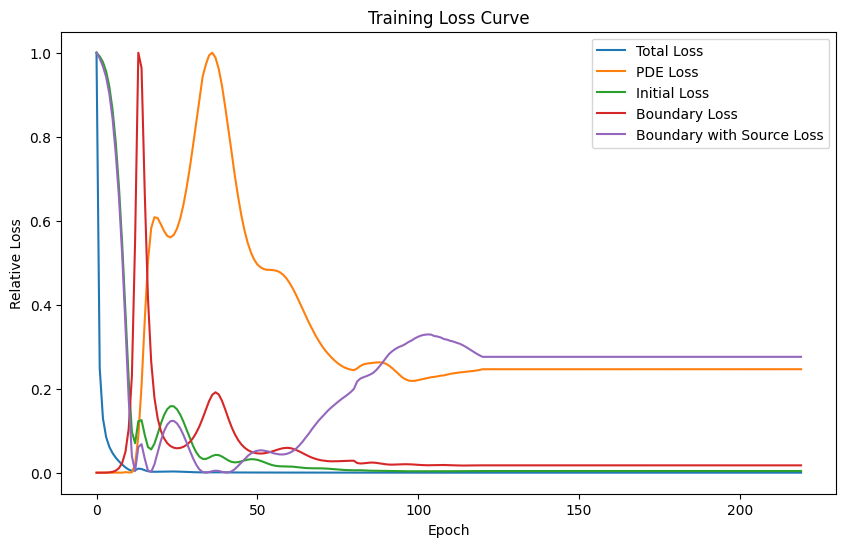

In [11]:
plt.figure(figsize=(10, 6))

# 绘制不同的损失历史曲线
plt.plot(history/np.max(history), label='Total Loss')
plt.plot(history_pde/np.max(history_pde), label='PDE Loss')
plt.plot(history_ic/np.max(history_ic), label='Initial Loss')
plt.plot(history_bc/np.max(history_bc), label='Boundary Loss')
plt.plot(history_bc_s/np.max(history_bc_s), label='Boundary with Source Loss')


# 添加标题和标签
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Relative Loss')
plt.legend()

# 显示绘图
plt.show()

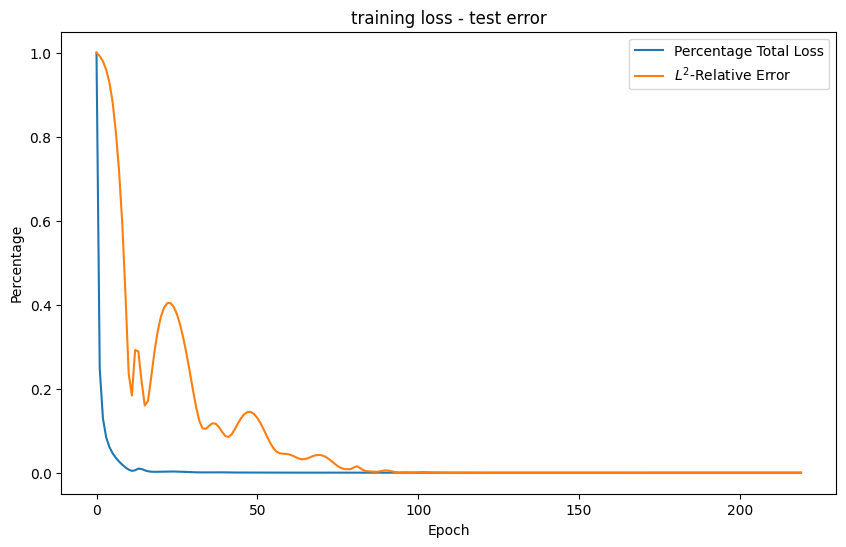

In [12]:
plt.figure(figsize=(10, 6))

plt.plot((history - np.min(history))/(np.max(history) - np.min(history)), label='Percentage Total Loss')
plt.plot((errs- np.min(errs))/(np.max(errs) - np.min(errs)), label='$L^2$-Relative Error')

# 添加标题和标签
plt.title('training loss - test error')
plt.xlabel('Epoch')
plt.ylabel('Percentage')
plt.legend()

# 显示绘图
plt.show()

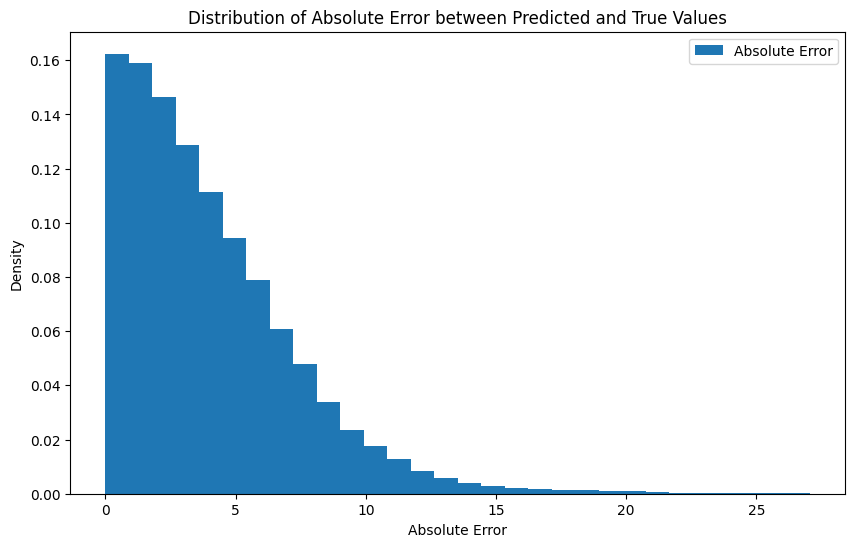

In [13]:
with torch.no_grad():
    plt.figure(figsize=(10, 6))

    U_pred = pinn.u(Xt)

    # 绘制直方图
    plt.hist(np.abs(U_pred - U), density=True, bins=30)

    # 添加标题和标签
    plt.title('Distribution of Absolute Error between Predicted and True Values')
    plt.xlabel('Absolute Error')
    plt.ylabel('Density')

    # 添加图例
    plt.legend(['Absolute Error'])

    # 显示图形
    plt.show()

In [14]:
def convert_back_tensor(Xt, U, Nt, max_time=1.0):
    # 获取空间点的数量
    N = Xt.shape[0] // Nt
    
    # 初始化 X 和 Ut
    X = torch.zeros((N, 3))
    Ut = torch.zeros((N, Nt))
    
    # 恢复 X 和 Ut
    for i in range(N):
        for j in range(Nt):
            idx = i * Nt + j
            X[i, :] = Xt[idx, :3]
            Ut[i, j] = U[idx]
    
    return X, Ut
    
_, Ut_pred = convert_back_tensor(Xt, U_pred, len(Ut[0]))

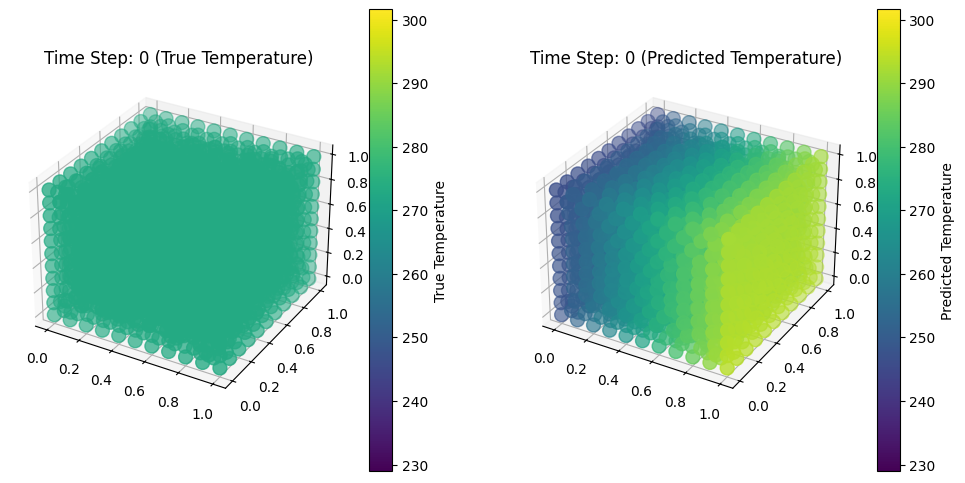

In [15]:
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams['axes.formatter.useoffset'] = False

fig = plt.figure(figsize=(12, 6))

# 固定颜色条的最大最小值
vmin = U.min()
vmax = U.max()

# 第一个3D绘图
ax1 = fig.add_subplot(121, projection='3d')
scat1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=Ut[:, 0], cmap='viridis')
cbar1 = fig.colorbar(scat1, ax=ax1)
cbar1.set_label('True Temperature')
scat1.set_clim(vmin, vmax)

# 第二个3D绘图
ax2 = fig.add_subplot(122, projection='3d')
scat2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=Ut_pred[:, 0], cmap='viridis')
cbar2 = fig.colorbar(scat2, ax=ax2)
cbar2.set_label('Predicted Temperature')
scat2.set_clim(vmin, vmax)


def update(frame):
    ax1.clear()
    ax2.clear()
    # 更新第一个3D绘图
    scat1 = ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=Ut[:, frame], cmap='viridis', vmin=vmin, vmax=vmax, s=100)
    ax1.set_title(f'Time Step: {frame} (True Temperature)')


    # 更新第二个3D绘图
    scat2 = ax2.scatter(X[:, 0], X[:, 1], X[:, 2], c=Ut_pred[:, frame], cmap='viridis', vmin=vmin, vmax=vmax, s=100)
    ax2.set_title(f'Time Step: {frame} (Predicted Temperature)')


    return scat1, scat2

ani = FuncAnimation(fig, update, frames=range(0, Ut.shape[1], 5), interval=100)

from IPython.display import HTML
HTML(ani.to_jshtml())